# SegmentIQ Full ML Pipeline (Production Section)

This section provides an end-to-end pipeline for:
- Data loading and cleaning
- K-Means clustering with Elbow + Silhouette evaluation
- PCA for 2D/3D visualization
- Random Forest segment prediction
- Model and artifact export for backend integration

In [1]:
# Core libraries
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    silhouette_score,
    classification_report,
    confusion_matrix,
    accuracy_score,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42

## 1) Load Dataset and Inspect

In [2]:
# Load dataset (default: Dataset_2.csv)
data_path = Path("Dataset_2.csv")
if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found: {data_path.resolve()}")

df = pd.read_csv(data_path)
print(f"Dataset shape: {df.shape}")
display(df.head())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values (top 10):")
display(df.isna().sum().sort_values(ascending=False).head(10).to_frame("missing_count"))

Dataset shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12



Data types:


,dtype
CUST_ID,str
BALANCE,float64
BALANCE_FREQUENCY,float64
PURCHASES,float64
ONEOFF_PURCHASES,float64
INSTALLMENTS_PURCHASES,float64
CASH_ADVANCE,float64
PURCHASES_FREQUENCY,float64
ONEOFF_PURCHASES_FREQUENCY,float64
PURCHASES_INSTALLMENTS_FREQUENCY,float64



Missing values (top 10):


,missing_count
MINIMUM_PAYMENTS,313
CREDIT_LIMIT,1
BALANCE,0
CUST_ID,0
BALANCE_FREQUENCY,0
PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0


## 2) Preprocess Data (Cleaning, Feature Selection, Scaling)

This block:
- Removes identifier columns from modeling features
- Keeps only numerical features for K-Means and PCA
- Handles missing values with median imputation
- Standardizes features for distance-based clustering

In [3]:
# Identify columns
id_candidates = [col for col in ["CUST_ID", "Customer_ID", "ID"] if col in df.columns]
id_col = id_candidates[0] if id_candidates else None

# Keep only numeric columns for clustering
feature_df = df.drop(columns=[id_col], errors="ignore").select_dtypes(include=[np.number]).copy()

# Track selected features for reproducibility
selected_features = feature_df.columns.tolist()
print(f"ID column: {id_col}")
print(f"Selected numeric features ({len(selected_features)}): {selected_features}")

# Impute + scale
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imputed = imputer.fit_transform(feature_df)
X_scaled = scaler.fit_transform(X_imputed)

X_imputed_df = pd.DataFrame(X_imputed, columns=selected_features, index=df.index)
X_scaled_df = pd.DataFrame(X_scaled, columns=selected_features, index=df.index)

display(X_scaled_df.head())

ID column: CUST_ID
Selected numeric features (17): ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


## 3) K-Means Model Selection (Elbow + Silhouette)

Evaluate cluster quality for k = 2..10 using:
- Inertia (Elbow Method)
- Silhouette Score

Best k by silhouette: 3


,k,inertia,silhouette
0,2,127784.534545,0.210043
1,3,111975.043593,0.250988
2,4,99061.939842,0.197679
3,5,91490.498040,0.193112
4,6,84826.592031,0.202860
5,7,79856.157018,0.207686
6,8,74484.880062,0.221698
7,9,69828.699269,0.226034
8,10,66466.414929,0.220438


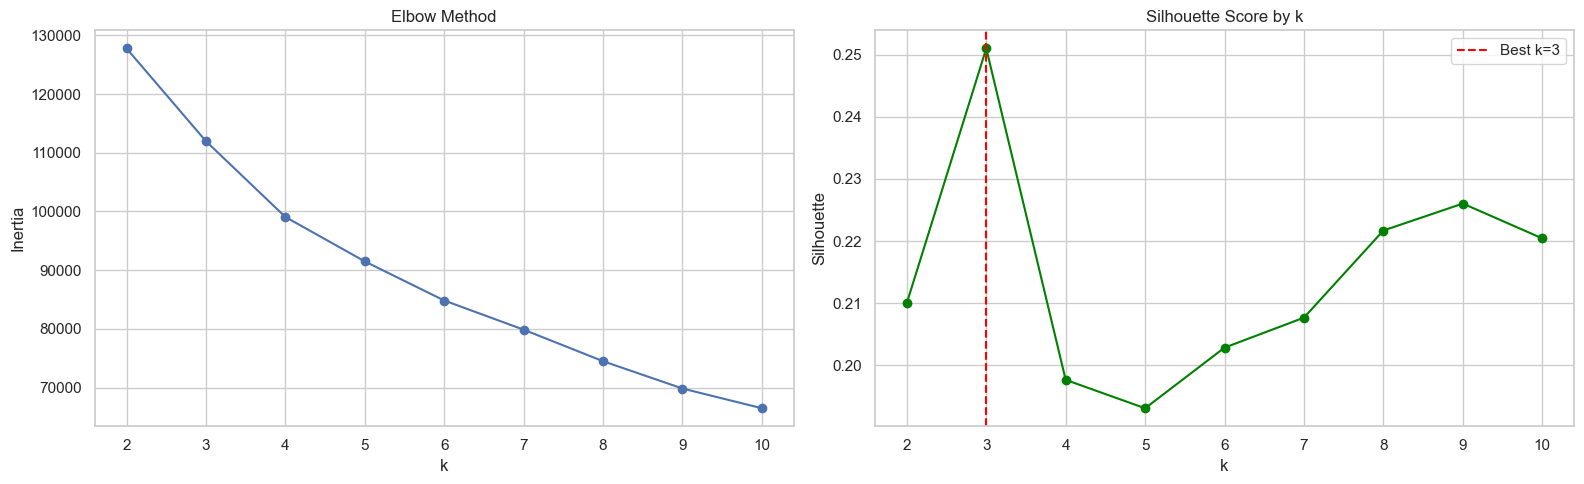

In [4]:
k_values = list(range(2, 11))
metrics_rows = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = model.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels_k)
    metrics_rows.append({"k": k, "inertia": model.inertia_, "silhouette": sil})

k_metrics = pd.DataFrame(metrics_rows)
best_k_by_silhouette = int(k_metrics.loc[k_metrics["silhouette"].idxmax(), "k"])

print(f"Best k by silhouette: {best_k_by_silhouette}")
display(k_metrics)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].plot(k_metrics["k"], k_metrics["inertia"], marker="o")
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

ax[1].plot(k_metrics["k"], k_metrics["silhouette"], marker="o", color="green")
ax[1].axvline(best_k_by_silhouette, color="red", linestyle="--", label=f"Best k={best_k_by_silhouette}")
ax[1].set_title("Silhouette Score by k")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette")
ax[1].legend()

plt.tight_layout()
plt.show()

## 4) Train Final K-Means Model and Attach Segment Labels

By default, we keep 4 segments for business storytelling.
If you want pure metric optimization, set `business_k = best_k_by_silhouette`.

Selected k: 4
Final silhouette score: 0.1977


,customer_count
Segment,
0,3977
1,409
2,1197
3,3367


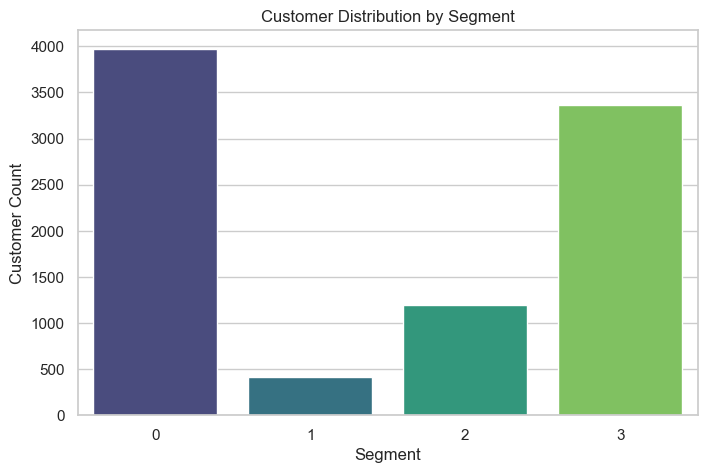

In [5]:
business_k = 4
selected_k = business_k

kmeans = KMeans(n_clusters=selected_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df_model = df.copy()
df_model["Segment"] = cluster_labels

final_silhouette = silhouette_score(X_scaled, cluster_labels)
print(f"Selected k: {selected_k}")
print(f"Final silhouette score: {final_silhouette:.4f}")

segment_counts = df_model["Segment"].value_counts().sort_index()
display(segment_counts.to_frame("customer_count"))

plt.figure(figsize=(8, 5))
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette="viridis")
plt.title("Customer Distribution by Segment")
plt.xlabel("Segment")
plt.ylabel("Customer Count")
plt.show()

## 5) PCA for 2D/3D Visualization

PCA 2D explained variance ratio: 47.61%


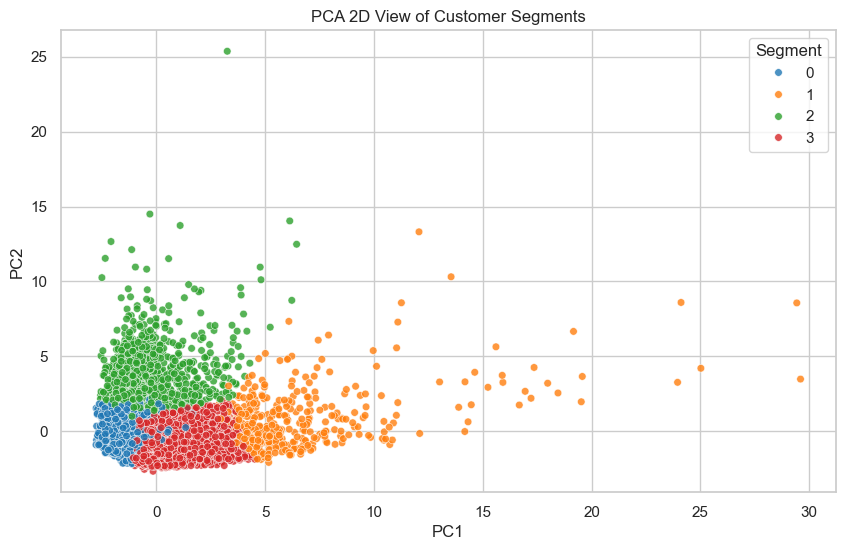

PCA 3D explained variance ratio: 56.42%


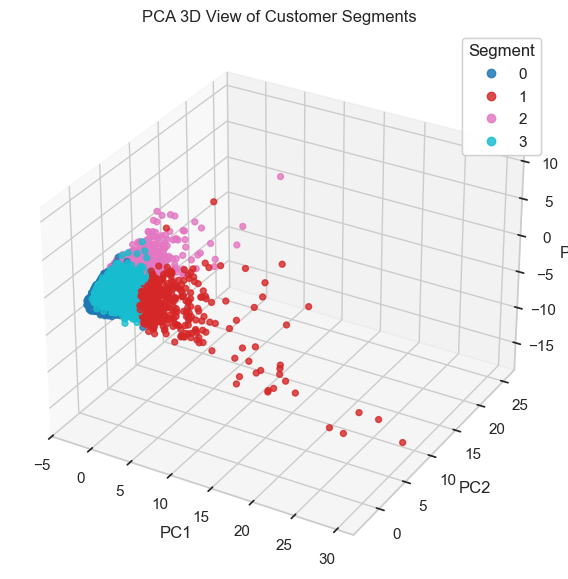

In [6]:
# PCA 2D
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca_2d, columns=["PC1", "PC2"])
pca_df["Segment"] = cluster_labels

explained_2d = pca_2d.explained_variance_ratio_.sum()
print(f"PCA 2D explained variance ratio: {explained_2d:.2%}")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Segment", palette="tab10", s=30, alpha=0.8)
plt.title("PCA 2D View of Customer Segments")
plt.show()

# PCA 3D (matplotlib)
pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca_3d = pca_3d.fit_transform(X_scaled)
explained_3d = pca_3d.explained_variance_ratio_.sum()
print(f"PCA 3D explained variance ratio: {explained_3d:.2%}")

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=cluster_labels, cmap="tab10", s=18, alpha=0.8)
ax.set_title("PCA 3D View of Customer Segments")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
legend1 = ax.legend(*scatter.legend_elements(), title="Segment")
ax.add_artist(legend1)
plt.show()

## 6) Correlation Heatmap (Feature Relationships)

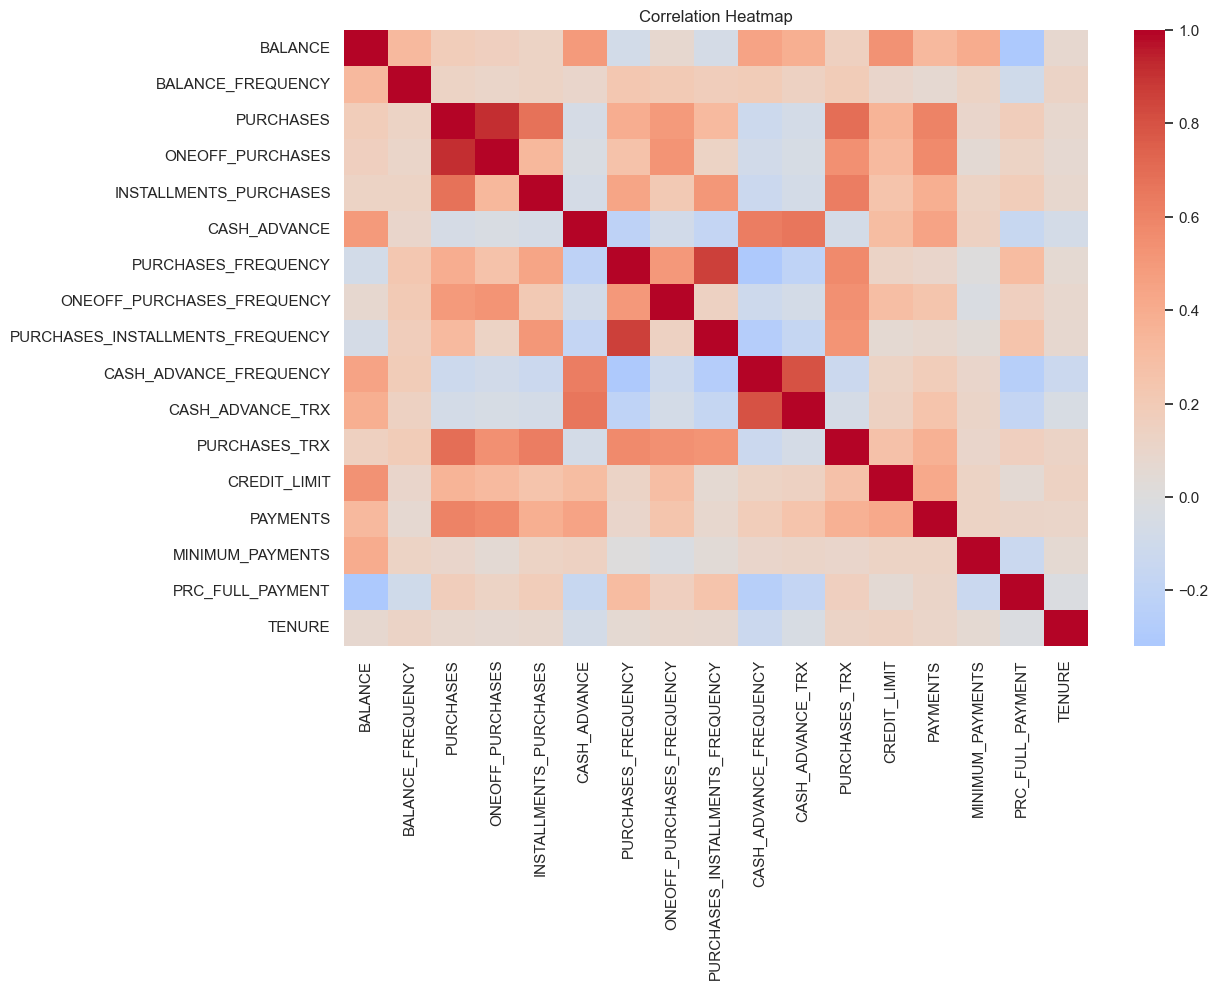

In [7]:
corr = X_imputed_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## 7) Random Forest Segment Prediction

Train a supervised model to predict segment labels for new customers.

Random Forest Accuracy: 0.9486

Classification Report:
              precision    recall  f1-score   support

           0      0.958     0.966     0.962       796
           1      0.900     0.878     0.889        82
           2      0.930     0.891     0.910       239
           3      0.950     0.957     0.953       673

    accuracy                          0.949      1790
   macro avg      0.934     0.923     0.929      1790
weighted avg      0.948     0.949     0.948      1790



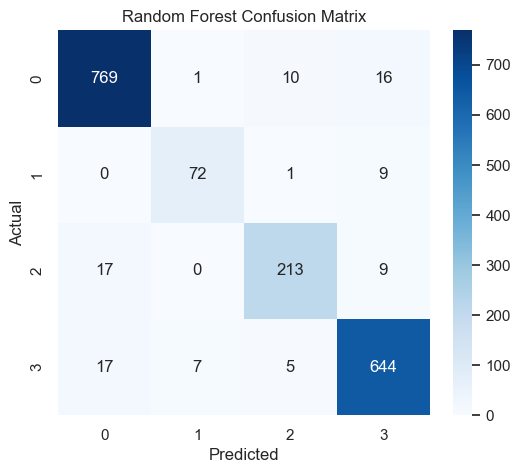

,feature,importance
2,PURCHASES,0.161053
6,PURCHASES_FREQUENCY,0.138893
11,PURCHASES_TRX,0.115570
5,CASH_ADVANCE,0.112848
10,CASH_ADVANCE_TRX,0.082398
3,ONEOFF_PURCHASES,0.064440
9,CASH_ADVANCE_FREQUENCY,0.060146
0,BALANCE,0.058005
13,PAYMENTS,0.041298
8,PURCHASES_INSTALLMENTS_FREQUENCY,0.039485


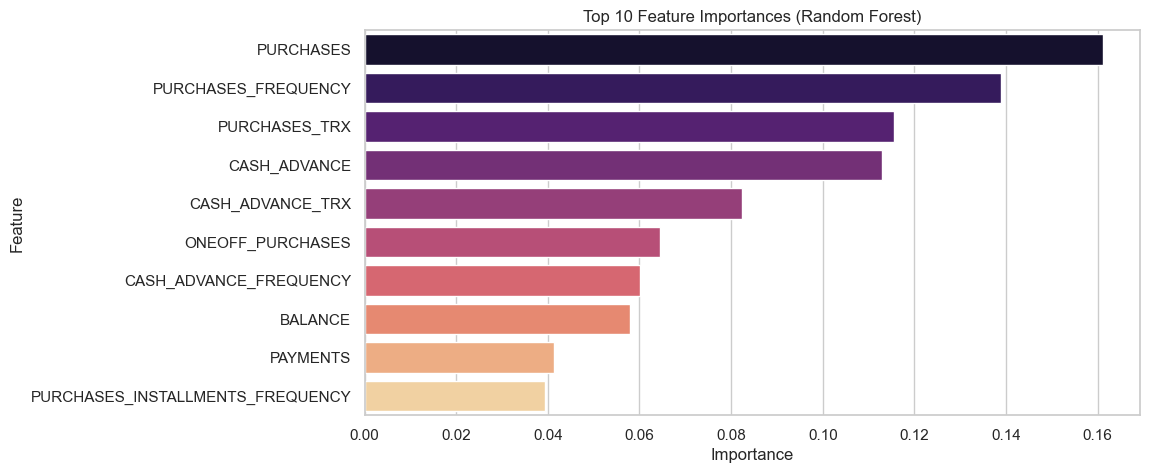

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed_df, cluster_labels, test_size=0.2, random_state=RANDOM_STATE, stratify=cluster_labels
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced",
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

importance_df = (
    pd.DataFrame({"feature": selected_features, "importance": rf_model.feature_importances_})
    .sort_values("importance", ascending=False)
)

display(importance_df.head(12))

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df.head(10), x="importance", y="feature", palette="magma")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 8) Segment Profiling (Business Insights Table)

In [9]:
segment_profile = df_model.groupby("Segment")[selected_features].mean().round(2)
segment_profile["customer_count"] = df_model["Segment"].value_counts().sort_index()
display(segment_profile)

# Save profile for dashboard / NOVA context
profile_path = Path("artifacts") / "segment_profile.csv"
profile_path.parent.mkdir(parents=True, exist_ok=True)
segment_profile.to_csv(profile_path)
print(f"Segment profile saved to: {profile_path.resolve()}")

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,customer_count
Segment,,,,,,,,,,,,,,,,,,
0,1012.66,0.79,270.04,209.94,60.37,596.51,0.17,0.09,0.08,0.11,2.13,2.90,3278.71,974.26,569.00,0.08,11.45,3977
1,3551.15,0.99,7681.62,5095.88,2587.21,653.64,0.95,0.74,0.79,0.07,2.09,89.36,9696.94,7288.74,1985.04,0.29,11.95,409
2,4602.45,0.97,501.86,320.19,181.76,4521.51,0.29,0.14,0.19,0.48,14.29,7.67,7546.16,3484.05,2020.80,0.03,11.39,1197
3,894.91,0.93,1236.18,593.97,642.48,210.57,0.89,0.30,0.71,0.04,0.79,22.09,4213.21,1332.19,646.02,0.27,11.59,3367


Segment profile saved to: C:\University NIBM\coding 2nd year\Personal\cust\new\artifacts\segment_profile.csv


## 9) Export Models and Metadata for Backend API

Exports:
- `imputer.joblib`
- `scaler.joblib`
- `kmeans.joblib`
- `rf_model.joblib`
- `selected_features.json`
- `metrics.json`

In [10]:
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(imputer, artifacts_dir / "imputer.joblib")
joblib.dump(scaler, artifacts_dir / "scaler.joblib")
joblib.dump(kmeans, artifacts_dir / "kmeans.joblib")
joblib.dump(rf_model, artifacts_dir / "rf_model.joblib")

with open(artifacts_dir / "selected_features.json", "w", encoding="utf-8") as f:
    json.dump(selected_features, f, indent=2)

metrics_payload = {
    "selected_k": int(selected_k),
    "best_k_by_silhouette": int(best_k_by_silhouette),
    "final_silhouette": float(final_silhouette),
    "rf_accuracy": float(rf_accuracy),
    "k_metrics": k_metrics.to_dict(orient="records"),
}

with open(artifacts_dir / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2)

print("Artifacts exported:")
for p in sorted(artifacts_dir.iterdir()):
    print(f"- {p.name}")

Artifacts exported:
- imputer.joblib
- kmeans.joblib
- metrics.json
- outlier_bounds.json
- rf_model.joblib
- scaler.joblib
- segment_profile.csv
- selected_features.json


## 10) Inference Helper (For API / Predictor Page)

Use this helper for backend integration where new customer data arrives as JSON.

In [11]:
def predict_customer_segment(new_customer: dict) -> int:
    """Predict customer segment using trained Random Forest model."""
    input_df = pd.DataFrame([new_customer])
    input_df = input_df.reindex(columns=selected_features)
    input_imputed = imputer.transform(input_df)
    pred_segment = rf_model.predict(input_imputed)[0]
    return int(pred_segment)

# Example usage with median profile values
example_customer = X_imputed_df.median().to_dict()
predicted_segment = predict_customer_segment(example_customer)
print(f"Predicted segment for example customer: {predicted_segment}")

Predicted segment for example customer: 0


## 11) Optional Benchmark: Logistic Regression vs Random Forest

This benchmark compares both models using the same train/test split and reports:
- Accuracy
- F1 Macro
- F1 Weighted

,Model,Accuracy,F1 Macro,F1 Weighted
0,Random Forest,0.9486,0.9286,0.9484
1,Logistic Regression,0.9050,0.8991,0.9055


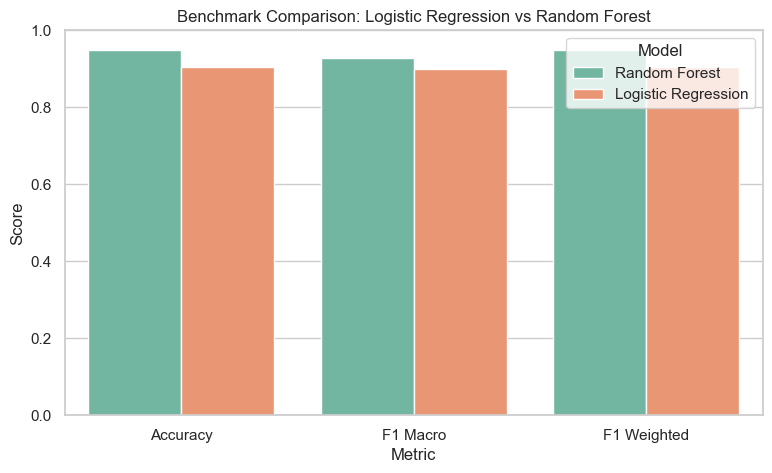

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# Reuse existing split if available; otherwise build it from pipeline variables.
if not all(name in globals() for name in ["X_train", "X_test", "y_train", "y_test"]):
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed_df,
        cluster_labels,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=cluster_labels,
    )

# Ensure Random Forest predictions for fair comparison
rf_pred_benchmark = rf_model.predict(X_test)

# Logistic Regression benchmark
log_reg = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
log_reg.fit(X_train, y_train)
lr_pred = log_reg.predict(X_test)

benchmark_df = pd.DataFrame(
    [
        {
            "Model": "Random Forest",
            "Accuracy": accuracy_score(y_test, rf_pred_benchmark),
            "F1 Macro": f1_score(y_test, rf_pred_benchmark, average="macro"),
            "F1 Weighted": f1_score(y_test, rf_pred_benchmark, average="weighted"),
        },
        {
            "Model": "Logistic Regression",
            "Accuracy": accuracy_score(y_test, lr_pred),
            "F1 Macro": f1_score(y_test, lr_pred, average="macro"),
            "F1 Weighted": f1_score(y_test, lr_pred, average="weighted"),
        },
    ]
)

benchmark_df = benchmark_df.sort_values("F1 Macro", ascending=False).reset_index(drop=True)
display(benchmark_df.round(4))

plt.figure(figsize=(9, 5))
plot_df = benchmark_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model", palette="Set2")
plt.title("Benchmark Comparison: Logistic Regression vs Random Forest")
plt.ylim(0, 1)
plt.legend(title="Model")
plt.show()